# Titanic Survival Prediction

## Objective

The objective of this project is to build a machine learning model that predicts whether a passenger survived the Titanic disaster using passenger information such as age, gender, passenger class, and fare.

## Workflow

1. Load the dataset
2. Explore the data
3. Clean missing values
4. Encode categorical features
5. Train a Logistic Regression model
6. Evaluate the model
7. Summarize findings


## Skills Demonstrated

- Data Loading
- Exploratory Data Analysis (EDA)
- Missing Value Analysis
- Feature Engineering
- Logistic Regression
- Model Evaluation

### 1. load the dataset


In [2]:
#import libraries - libraries needed - numpy - seaborn - pandas - matplotlib.pyplot

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn 


In [3]:
#import data set 
df = pd.read_csv('C:\\Users\\user\\Documents\\Github\\titanic-survival-prediction\\Data\\train.csv')

### 2. Explore the data

In [4]:
# 3. Dataset Overview : exploring data infrormation
#look at the data
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
#the type of each feature - we have three typs (int - float - object)
# (Sex - Embarke -Cabin - Ticket - Name ) - categorical data 
# (Age - Fare - Pclass - SibSp - Parch)  - numerical data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:

df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#The dataset contains 891 rows and 12 columns.
df.shape

(891, 12)

In [8]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [9]:
#The Age column contains missing values.
#Cabin has many missing values.
#PassengerId appears to be an identifier.
#The target variable is Survived
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Initial Dataset Observations

- Dataset contains 891 passengers.
- Age has 177 missing values.
- Cabin has 687 missing values.
- Data contains numerical and categorical features.
- Target variable is Survived.

In [10]:
df[['Name', 'SibSp', 'Parch']].head(15)

,Name,SibSp,Parch
0,"Braund, Mr. Owen Harris",1,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0
2,"Heikkinen, Miss. Laina",0,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0
4,"Allen, Mr. William Henry",0,0
5,"Moran, Mr. James",0,0
6,"McCarthy, Mr. Timothy J",0,0
7,"Palsson, Master. Gosta Leonard",3,1
8,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,2
9,"Nasser, Mrs. Nicholas (Adele Achem)",1,0


In [11]:
#Counting how many passangers survived
#only 342 survived
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [12]:
#Counting how many males and females are there
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [13]:
#Counting How many passengers are in each class 
#pclass: A proxy for socio-economic status (SES)
#1st = Upper
#2nd = Middle
#3rd = Lower

df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


Feature	  >     Decision	  >      Reason
---------------------------------------------------------
PassengerId	 >  ❌ Drop	   >      Identifier
----------------------------------------------------------
Name	   >    ❌ Drop	  >       Identifier 
-----------------------------------------------------------
Ticket	   >    ❌ Drop	   >      Complex text feature; we'll keep the project focused
-----------------------------------------------------------
Cabin	   >    ❌ Drop	   >      About 77% missing values
------------------------------------------------------------
Sex	       >    ✅ Keep	   >      Strong potential predictor
------------------------------------------------------------
Age	        >   ✅ Keep	   >      Important feature; missing values can be imputed
--------------------------------------------------------------
Fare	   >    ✅ Keep	   >      Could relate to survival
--------------------------------------------------------------
Pclass	   >    ✅ Keep	   >      Represents passenger class; likely informative
------------------------------------------------------------
SibSp	   >    ✅ Keep	  >       number of siblings or spouses traveled with this passenger
------------------------------------------------------------
Parch	  >     ✅ Keep	  >       number of parents or children traveled with this passenger
------------------------------------------------------------
Embarked	>   🤔  Keep	>          Categorical feature that we'll encode later
-------------------------------------------------------------
Survived	>   🎯 Target	>      The variable we're predicting
-------------------------------------------------------------

### 3.Data Cleaning & Preprocessing

 3.1 Handle Missing Values



We find out that we have these missing values :

Age       → 177 missing

Cabin     → 687 missing  - we remove Cabin since the mijority is missing values

Embarked  → 2 missing

In [14]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# we need to impute the missing ages.
# Replace missing values with a reasonable value.
# there are several possibilities for filling the missing values : 
# Mean : Replace missing ages with average age   Median : Replace missing ages with middle age   Mode : Replace missing ages with most common age
# we gana use the median to fill the missing value The median is much more resistant to outliers.

In [16]:
#First we need to inspect the distribution of the age . Does the distribution look symmetric, or does it look somewhat skewed

df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

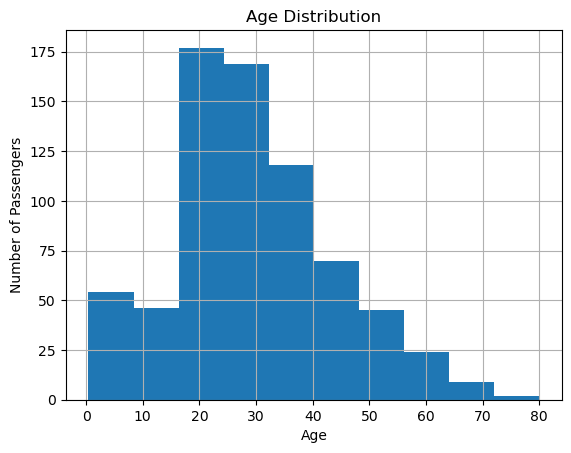

Median age =  28.0


In [19]:
df['Age'].hist()
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution')
plt.show()

#------------------------------------------------------------
#Calculate the median 
age_median = df['Age'].median()
print("Median age = " , age_median)

## Handling Missing Values

### Age

The Age feature contains 177 missing values. The age distribution is right-skewed, with most passengers concentrated at younger ages and a longer tail toward older passengers.

Because the median is less sensitive to extreme values than the mean, the median is a suitable simple imputation strategy for this dataset.

The median age is 28 years, so missing Age values will be replaced with 28.

### Embarked

The Embarked feature contains only 2 missing values. Southampton (S) is the most common embarkation port, with 644 passengers.

Therefore, the missing Embarked values will be replaced with the mode, `S`.

In [ ]:
# we use the median instead of the mean becouse the mean can be influenced by unusually high or low values.
# Median is a safer simple choice than mean for filling missing Age values.
# Skewness supports the decision to prefer the median because the median is less sensitive to extreme values.
# let's fill the missing values of age using the medianS
df['Age'] = df['Age'].fillna(age_median)

In [21]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


 For the Embarked column there are only two missing values so we will use :
Mode : Replace missing Embarked with most common Embarked locations 

In [24]:
# first inspect the uniqe values of Embarked column
df['Embarked'].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [ ]:
#Finding the most common port using Mode
# There are only two missing values in Embarked, and Southampton (S) is by far the most common category. We will use the mode to fill the missing values.
df['Embarked'].mode()[0]

'S'

In [26]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [27]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

## Remove Cabin

The Cabin feature contains 687 missing values out of 891 passengers, which is approximately 77% of the dataset.

Because such a large proportion of the values are missing, and because handling Cabin is outside the scope of this introductory project, the feature will be removed.

In [28]:
df = df.drop(columns=['Cabin'])

In [29]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')

In [30]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64